# **Klasifikasi Kondisi Sistem Pesawat Ulang Alik (Shuttle) Berdasarkan Data Sensor Menggunakan Algoritma Decision Tree**

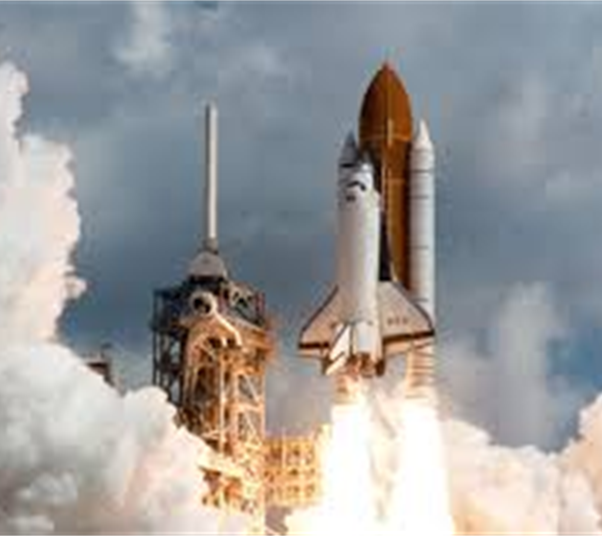

### Latar Belakang Masalah
Jumlah sensor shuttle serta data nilainya yang sulit diinterpretasikan oleh manusia menyulitkan klasifikasi kondisi sistem shuttle secara manual, hal ini mengharuskan adanya sistem AI yang membantu dalam klasifikasi kondisi sistem shuttle guna peluncuran yang berhasil secara maksimal.

### Tujuan
1. Mengidentifikasi pola nilai dari data sensor yang ada.
2. Mengembangkan sistem AI Decision Tree yang mampu mengklasifikasikan kondisi sistem shuttle secara akurat (Rad Flow, Fpv Close, Fpv Open, High, Bypass, Bpv Close, dan Bpv Open).

----------------

### Informasi Dataset

**Kolom**

A1 : 

Merepresentasikan waktu atau urutan pengambilan data sensor pada sistem shuttle. 

A2-A9 : 

Merupakan nilai numerik dari berbagai sensor pada sistem shuttle yang menggambarkan kondisi operasional sistem pada saat tertentu. 

class : 

Merupakan atribut target yang menunjukkan kondisi sistem shuttle berdasarkan data sensor. Label direpresentasikan dalam bentuk nilai numerik dengan kategori sebagai berikut: 1 = Rad Flow, 2 = Fpv Close, 3 = Fpv Open, 4 = High, 5 = Bypass, 6 = Bpv Close, dan 7 = Bpv Open. Nilai ini menjadi target dalam proses klasifikasi untuk menentukan kondisi operasional sistem shuttle.


--------

# A. Exploratory Data Analysis

In [215]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [216]:
df = pd.read_csv('shuttle.csv')
df.head(10)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,class
0,50.0,21.0,NaN,0.0,28.0,0.0,27.0,48.0,NaN,2.0
1,55.0,0.0,92.0,0.0,0.0,26.0,36.0,NaN,56.0,4.0
2,53.0,0.0,82.0,0.0,52.0,-5.0,29.0,30.0,2.0,1.0
3,37.0,0.0,76.0,0.0,28.0,18.0,40.0,48.0,8.0,1.0
4,37.0,0.0,79.0,0.0,34.0,-26.0,NaN,46.0,2.0,1.0
5,85.0,0.0,88.0,-4.0,6.0,1.0,3.0,83.0,80.0,5.0
6,56.0,0.0,81.0,0.0,-4.0,11.0,25.0,86.0,62.0,4.0
7,55.0,-1.0,95.0,NaN,54.0,-4.0,40.0,41.0,2.0,1.0
8,53.0,8.0,77.0,0.0,NaN,0.0,23.0,48.0,24.0,4.0
9,37.0,0.0,101.0,-7.0,28.0,0.0,64.0,73.0,8.0,1.0


In [217]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58000 entries, 0 to 57999
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   A1      55042 non-null  float64
 1   A2      55123 non-null  float64
 2   A3      55029 non-null  float64
 3   A4      55051 non-null  float64
 4   A5      55088 non-null  float64
 5   A6      55111 non-null  float64
 6   A7      55072 non-null  float64
 7   A8      55081 non-null  float64
 8   A9      55134 non-null  float64
 9   class   55099 non-null  float64
dtypes: float64(10)
memory usage: 4.4 MB


**Insight:**
- Jumlah non-null yang bervariasi menunjukan ada beberapa data kosong (Nan) pada dataset yang mungkin pada saat tertentu, suatu sensor gagal memberikan data
- Semua kolom sudah dalam bentuk numerik kontiyu (kecuali class yang dimana itu numerik kategorikal)

**Tindakan:**
- Melakukan penanganan data kosong pada tahap selanjutnya

In [218]:
df.describe()

,A1,A2,A3,A4,A5,A6,A7,A8,A9,class
count,55042.000000,55123.000000,55029.000000,55051.000000,55088.000000,55111.000000,55072.000000,55081.000000,55134.000000,55099.000000
mean,48.232677,0.102462,85.358266,0.298632,34.542986,1.862169,37.083436,50.864726,13.932818,1.694386
std,12.227260,76.824536,8.904360,36.403085,21.682285,218.649159,13.136285,21.389972,25.600472,1.350744
min,27.000000,-4624.000000,21.000000,-3939.000000,-188.000000,-26739.000000,-48.000000,-353.000000,-356.000000,1.000000
25%,38.000000,0.000000,79.000000,0.000000,26.000000,-5.000000,31.000000,37.000000,0.000000,1.000000
50%,45.000000,0.000000,83.000000,0.000000,42.000000,0.000000,39.000000,44.000000,2.000000,1.000000
75%,55.000000,0.000000,89.000000,0.000000,46.000000,5.000000,42.000000,60.000000,14.000000,1.000000
max,126.000000,5075.000000,149.000000,3830.000000,436.000000,15164.000000,105.000000,270.000000,244.000000,7.000000


**Insight:**
- Fitur A2, A3 dan A4 memiliki data yang mengumpul di nilai 0, tetapi ada juga data yang sangat berbeda sigifikan 

In [219]:
df = df.sort_values('A1')
df.reset_index(drop=True, inplace=True)
df.head(10)

,A1,A2,A3,A4,A5,A6,A7,A8,A9,class
0,27.0,-105.0,78.0,0.0,42.0,10.0,51.0,37.0,-14.0,1.0
1,27.0,-63.0,78.0,0.0,42.0,NaN,51.0,37.0,-14.0,1.0
2,27.0,-227.0,78.0,0.0,42.0,13.0,51.0,37.0,-14.0,1.0
3,36.0,-2.0,82.0,0.0,36.0,0.0,46.0,46.0,0.0,1.0
4,36.0,-5.0,75.0,0.0,36.0,0.0,39.0,39.0,0.0,1.0
5,36.0,-5.0,82.0,0.0,36.0,0.0,46.0,46.0,0.0,1.0
6,36.0,-2.0,81.0,0.0,36.0,0.0,45.0,45.0,0.0,1.0
7,36.0,-5.0,NaN,0.0,NaN,0.0,40.0,40.0,0.0,1.0
8,36.0,-3.0,77.0,0.0,36.0,NaN,41.0,41.0,0.0,1.0
9,36.0,NaN,83.0,3.0,36.0,0.0,46.0,46.0,0.0,1.0


**Insight:**
- Setiap kondisi mengumpul atau terjadi pada jangka waktu tertentu saja (seperti kondisi aliran fluida pada sistem radiator atau sistem pendingin yang sedang berjalan normal) diatas menunjukan terjadi pada waktu awal awal proses, yang menunjukan adanya tahap kondisi sistem per waktu nya

In [220]:
df.isna().sum()

A1       2958
A2       2877
A3       2971
A4       2949
A5       2912
A6       2889
A7       2928
A8       2919
A9       2866
class    2901
dtype: int64

**Insight:**
- Terlihat adanya jumlah data kosong pada setiap kolom dan di sekitar jumlah 2900 an

**Tindakan:**
- Melakukan penanganan dengan menghapus

**Alasan:**
- Manipulasi data data kosong dengan mengisi dengan mean atau median suatu kolom, tidak akan mencerminkan kondisi sebenarnya pada shuttle tersebut, sehingga akan berbahaya mengingat shuttle akan digunakan untuk penerbangan ke luar angkasa. 
- Data yang dihapus seharusnya tidak akan berpengaruh, dikarenakan pada suatu waktu (A1) yang sama masih ada data lain yang memberi informasi serupa

In [221]:
df.duplicated().sum()

268

In [222]:
df['class'].unique()

array([ 1., nan,  7.,  3.,  2.,  4.,  6.,  5.])

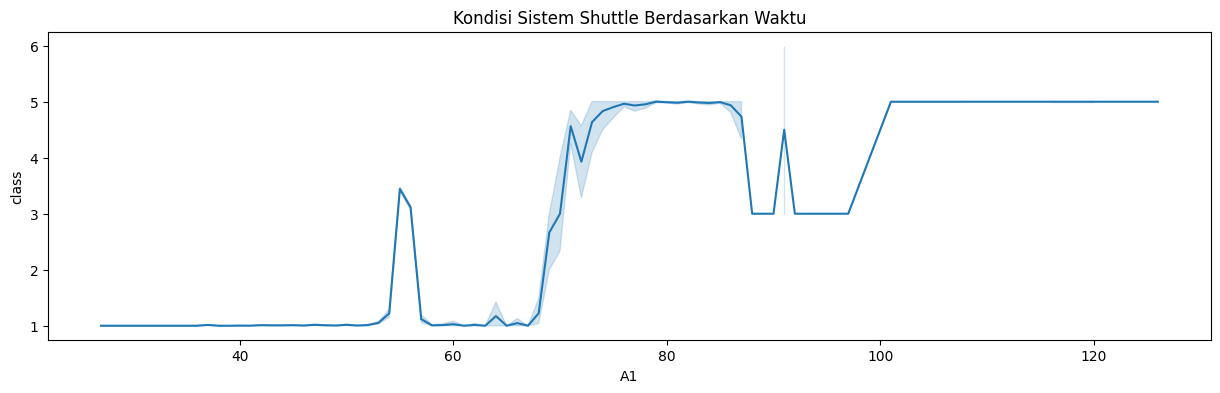

In [223]:
plt.figure(figsize=[15,4])
sns.lineplot(df, x='A1', y=df['class'])
plt.title('Kondisi Sistem Shuttle Berdasarkan Waktu')
plt.show()

**Insight:**
- Membuktikan bahwa suatu kondisi sistem terjadi sesuai runtutan prosedur penerbangan shuttle
- (Waktu awal - sekitar 52) Aliran fluida (bahan bakar) atau pendingin normal, yang mungkin menujukan proses pengisian fluida kedalam shuttle sebelum peluncuran
- (Waktu 52 - sekitar 58) Tekanan mendadak tinggi, yang mungkin menunjukan proses peluncuran shuttle ke luar angkasa
- (Waktu 58 - sekitar 70) Pendingin kembali normal diikuti dengan aliran fluida yang dihentikan, mungkin menunjukan proses henti pembakaran untuk proses pemishan suatu bagian shuttle
- (Waktu 70 - dst) Terjadi kombinasi penggunaan aliran fluida normal dan bypass walau jarang untuk bypass serta ada saat terjadi tekanan tinggi, menunjukan kombinasi runtutan proses peluncuran yang lebih kompleks ke orbit bumi


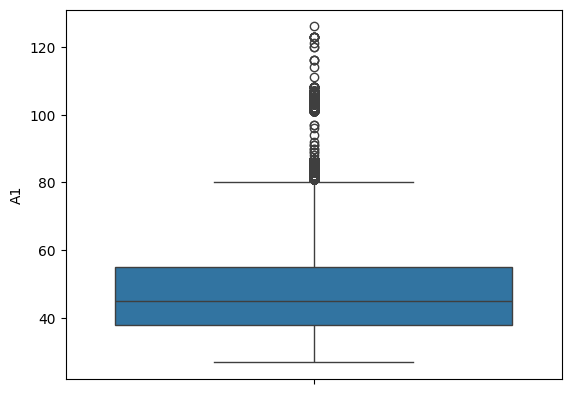

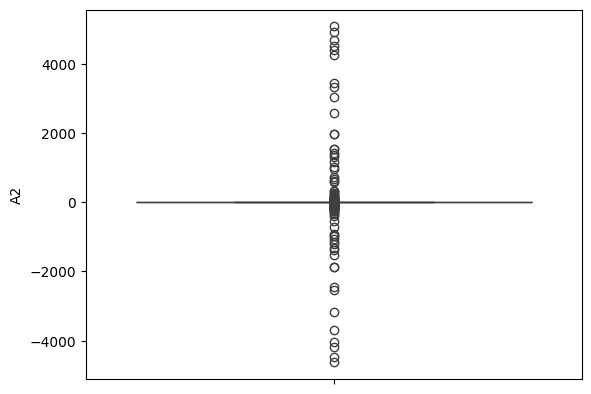

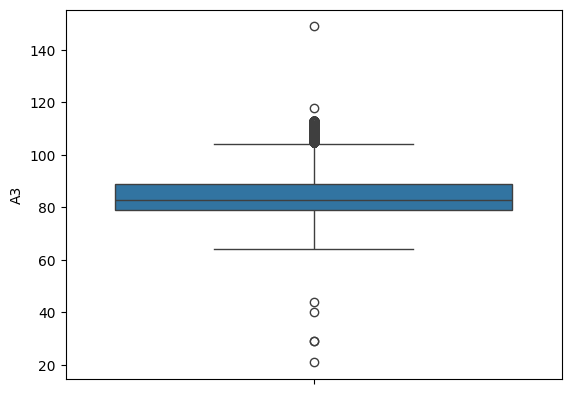

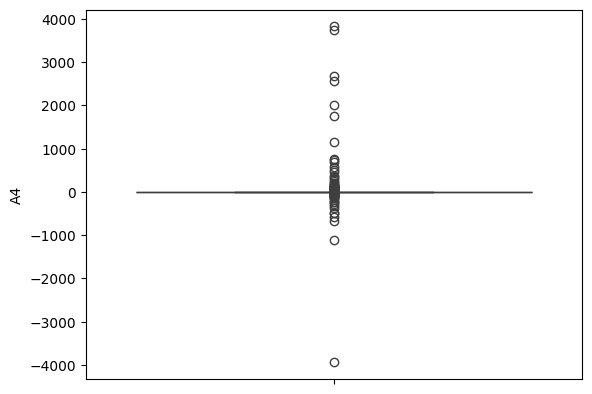

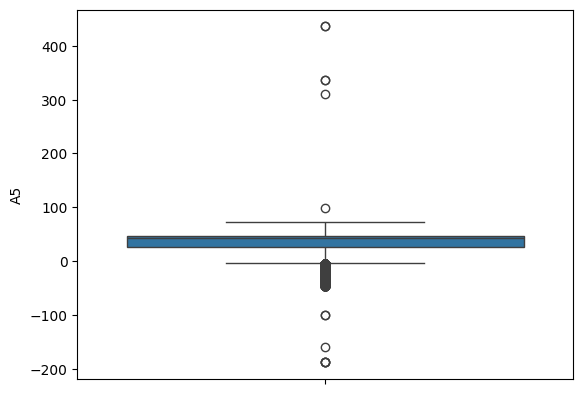

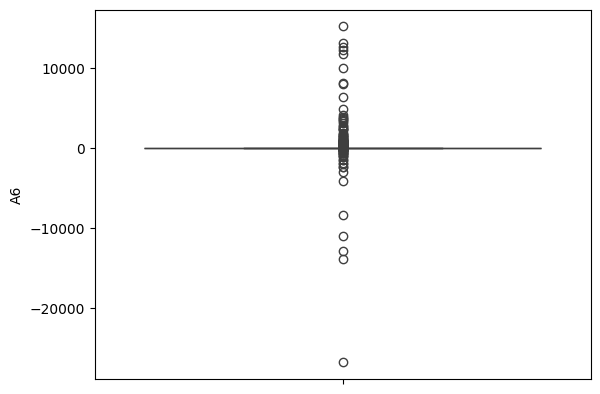

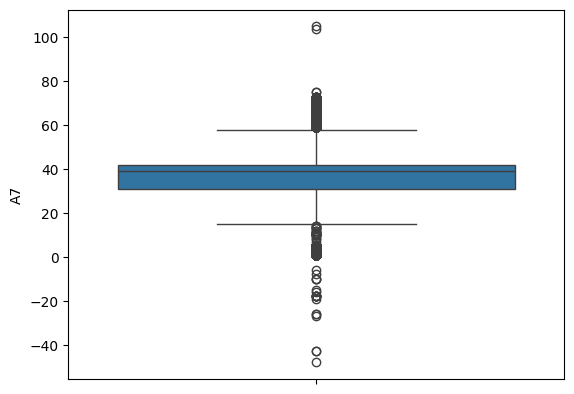

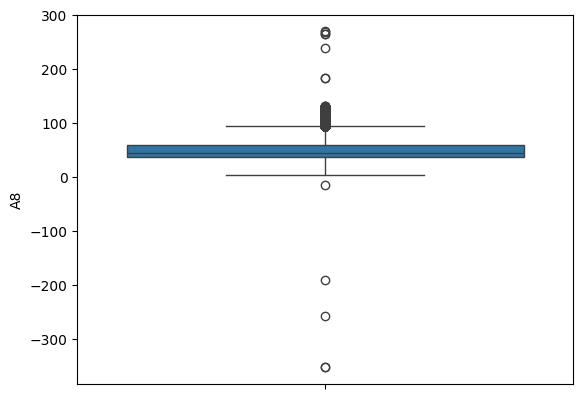

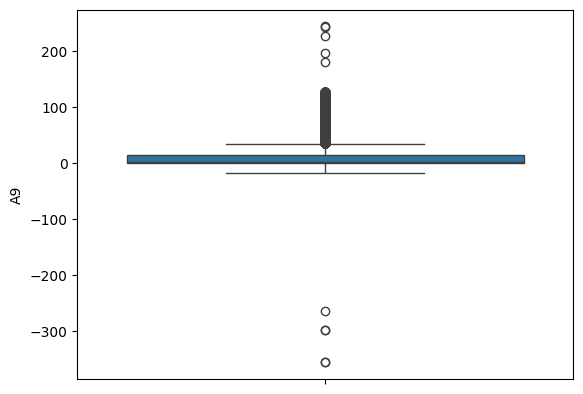

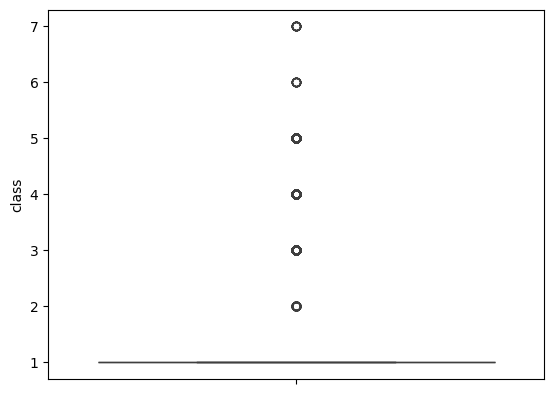

In [224]:
for i in df.columns:
    sns.boxplot(df[i])
    plt.show()

**Insight:**
- Teradapat adanya data yang dianggap outlier oleh plot box

**Tindakan:**
- Tidak melakukan penghapusan outlier karena ini data asli dari suatu sensor shuttle

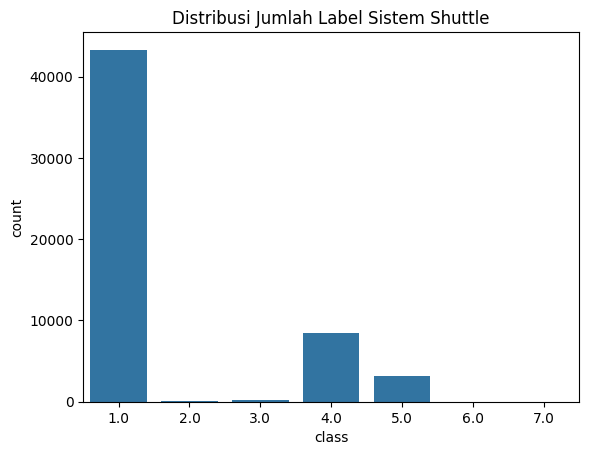

In [225]:
sns.countplot(x=df['class'])
plt.title('Distribusi Jumlah Label Sistem Shuttle')
plt.show()

In [226]:
df[df['class'] == 7]

,A1,A2,A3,A4,A5,A6,A7,A8,A9,class
543,37.0,-977.0,76.0,0.0,20.0,0.0,39.0,55.0,16.0,7.0
1157,37.0,-3700.0,106.0,-1.0,34.0,-2.0,69.0,72.0,4.0,7.0
1408,37.0,-977.0,75.0,-2.0,28.0,21.0,38.0,46.0,8.0,7.0
1495,37.0,-1521.0,77.0,0.0,20.0,0.0,40.0,57.0,16.0,7.0
1594,37.0,-2544.0,106.0,-2.0,34.0,-10.0,69.0,72.0,4.0,7.0
1758,37.0,-1329.0,76.0,NaN,36.0,3.0,39.0,40.0,2.0,7.0
3363,37.0,NaN,77.0,0.0,20.0,-1.0,40.0,56.0,16.0,7.0
4340,37.0,-1203.0,106.0,32.0,34.0,-8.0,69.0,72.0,4.0,7.0
6349,37.0,-1369.0,106.0,-1.0,34.0,NaN,69.0,72.0,4.0,7.0
8221,37.0,-4184.0,106.0,40.0,34.0,-10.0,69.0,NaN,4.0,7.0


In [227]:
df[df['class'] == 6]

,A1,A2,A3,A4,A5,A6,A7,A8,A9,class
39713,55.0,NaN,76.0,0.0,20.0,0.0,20.0,55.0,34.0,6.0
44859,55.0,1029.0,75.0,-3.0,28.0,26.0,20.0,46.0,26.0,6.0
50668,57.0,1149.0,80.0,NaN,34.0,0.0,23.0,46.0,24.0,6.0
51679,64.0,1532.0,77.0,0.0,20.0,0.0,14.0,57.0,44.0,6.0
51716,64.0,1532.0,106.0,-2.0,34.0,-35.0,42.0,72.0,30.0,6.0
52372,79.0,1958.0,82.0,-3.0,44.0,-5.0,3.0,38.0,34.0,6.0
52532,79.0,1963.0,88.0,0.0,44.0,0.0,NaN,NaN,34.0,6.0
53368,82.0,2561.0,106.0,-4.0,34.0,-20.0,24.0,72.0,48.0,6.0
53411,82.0,736.0,106.0,-3.0,34.0,-16.0,24.0,NaN,48.0,6.0
54184,91.0,3049.0,106.0,-4.0,36.0,1.0,15.0,69.0,NaN,6.0


**Insight:**
- Terdapat adanya imbalanced data, menunjukan proses aliran fluida atau sistem pendingin lancar mendominasi isi dataset
- Proses penghentian fluida dan pembukaan fluida dilakukan hanya pada sedikit waktu
- Proses bypass ditutup dan bypass dibuka dilakukan hanya pada sangat sedikit waktu yang menunjukan jalur alternatif jarang sekali digunakan, yang menunjukan jarang sekali ada kesalahan pada jalur utama.

**Tindakan pada preprocesing :**
- Melakukan oversampling data minoritas menjadi 10000 supaya tidak terlalu didominasi data buatan, dan tidak menghapus data berharga asli

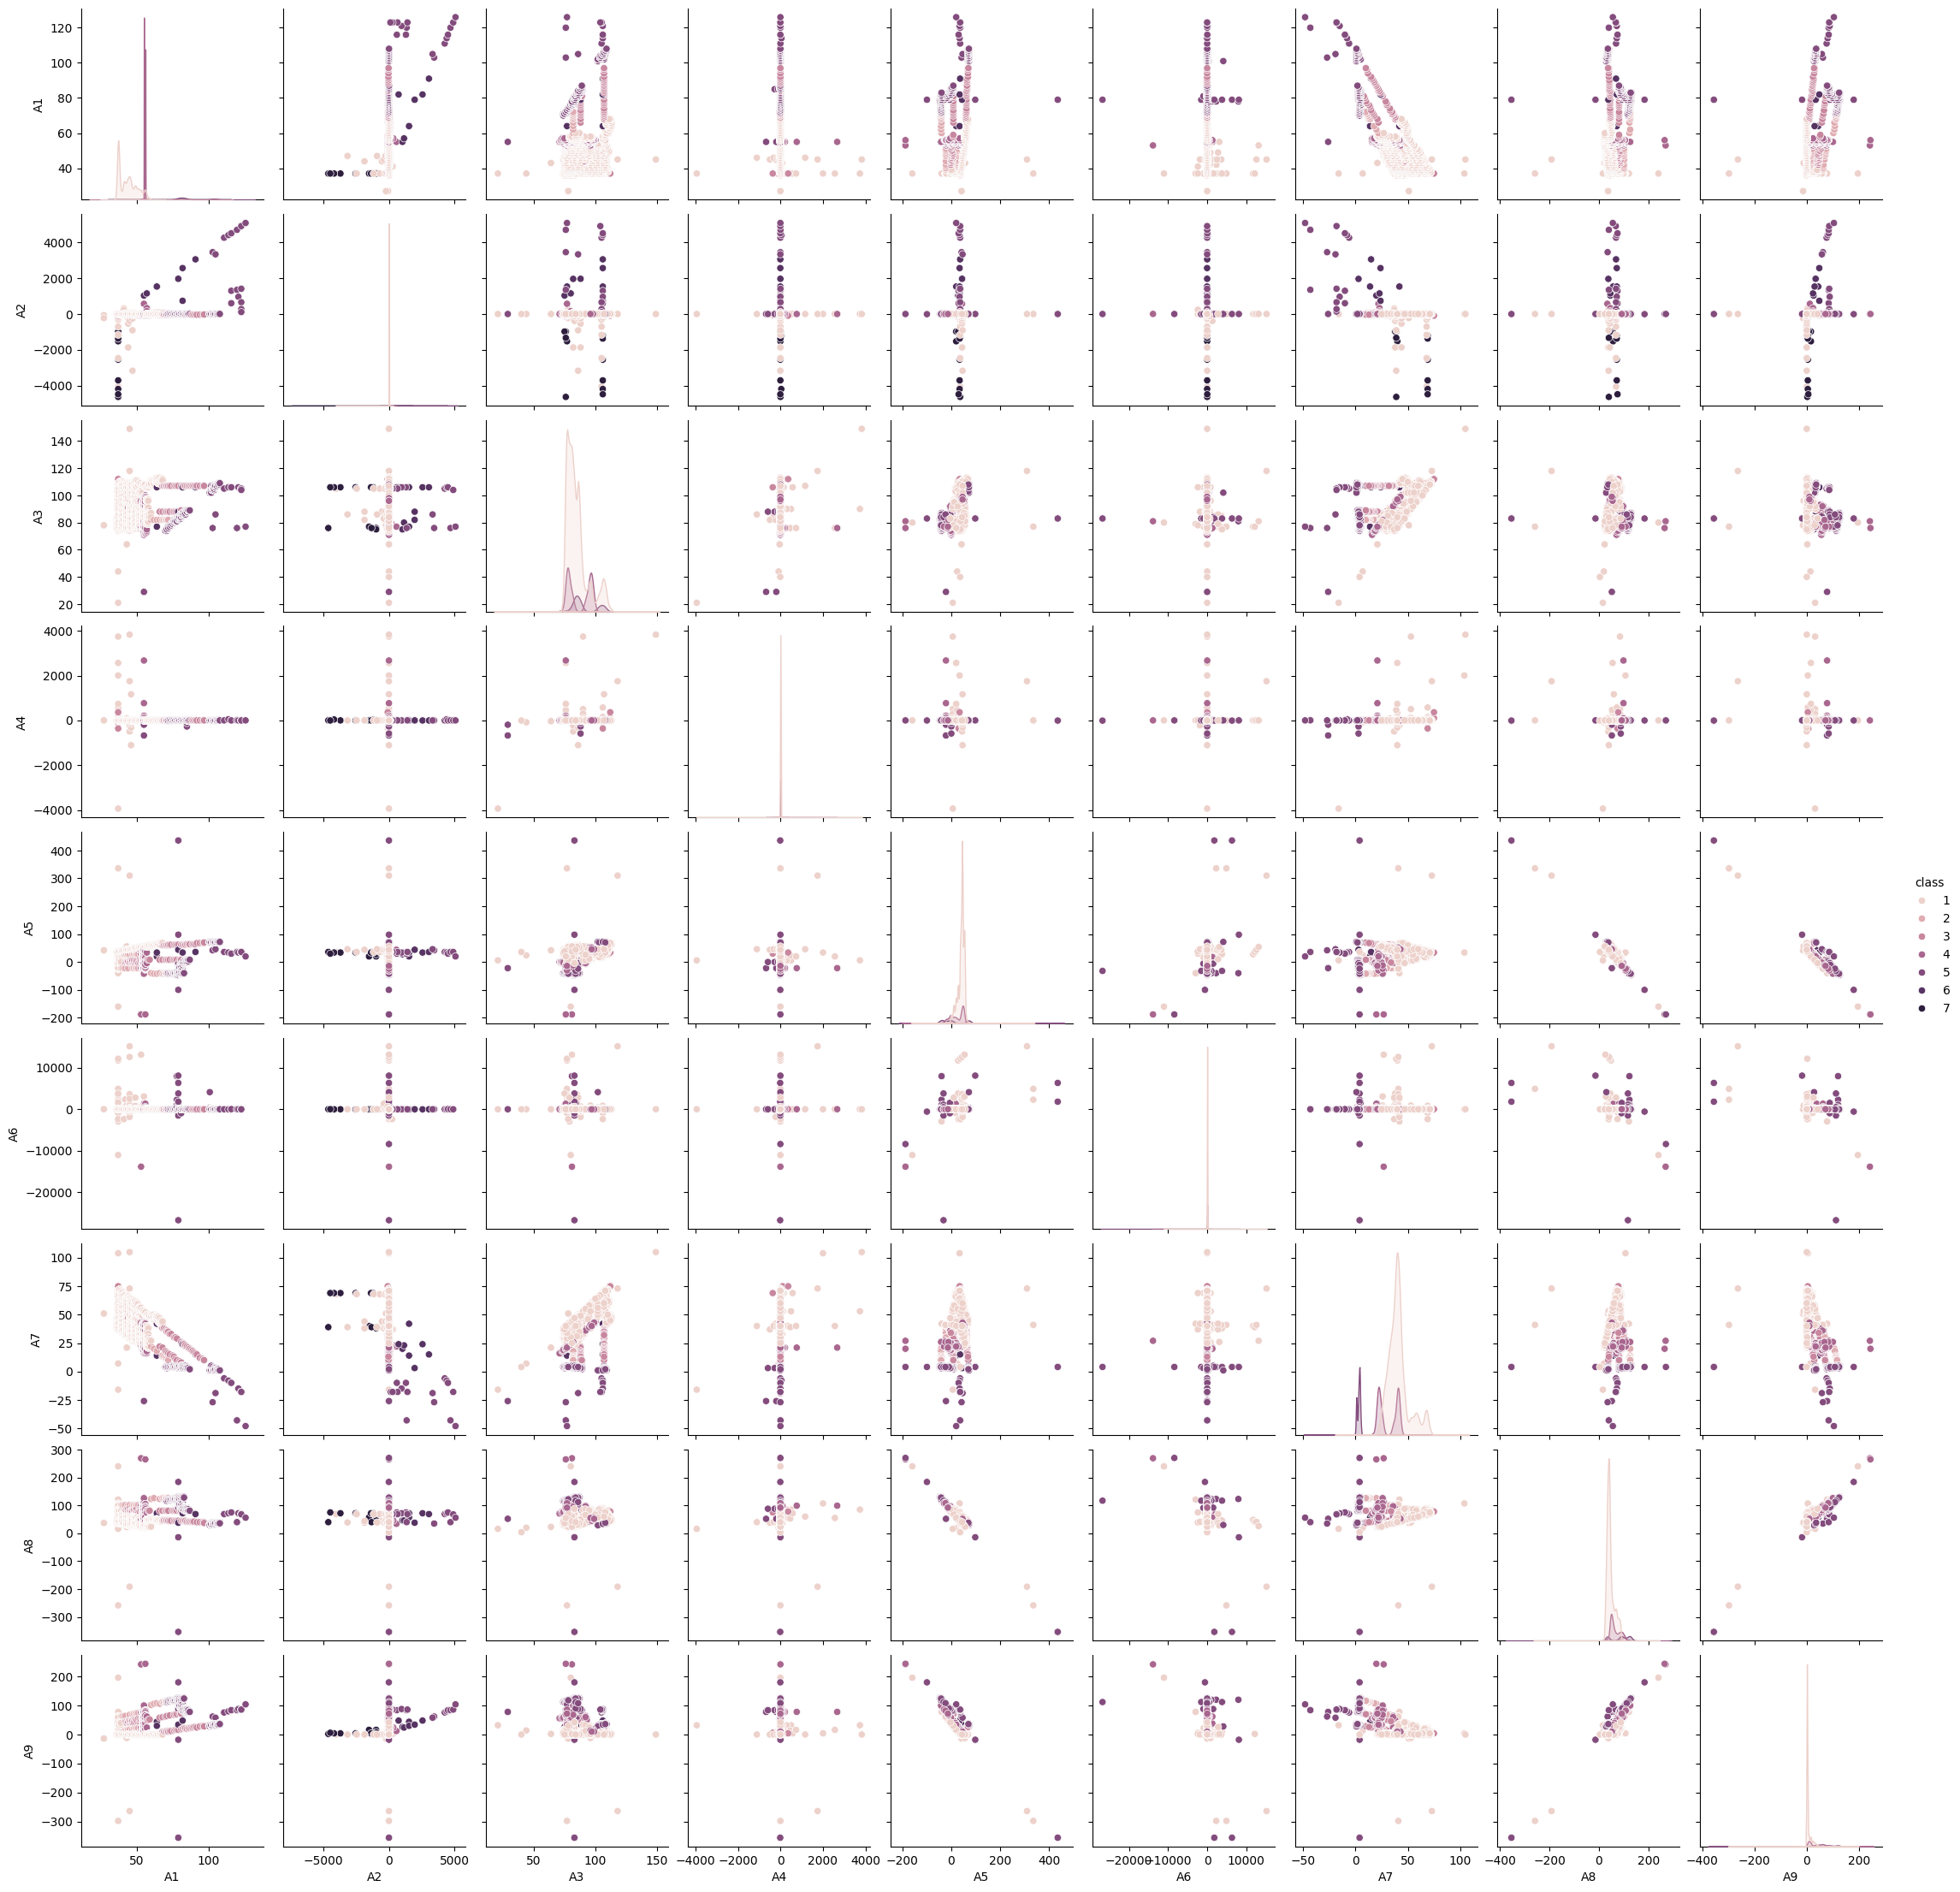

In [228]:
sns.pairplot(data=df, hue='class')

<Axes: >

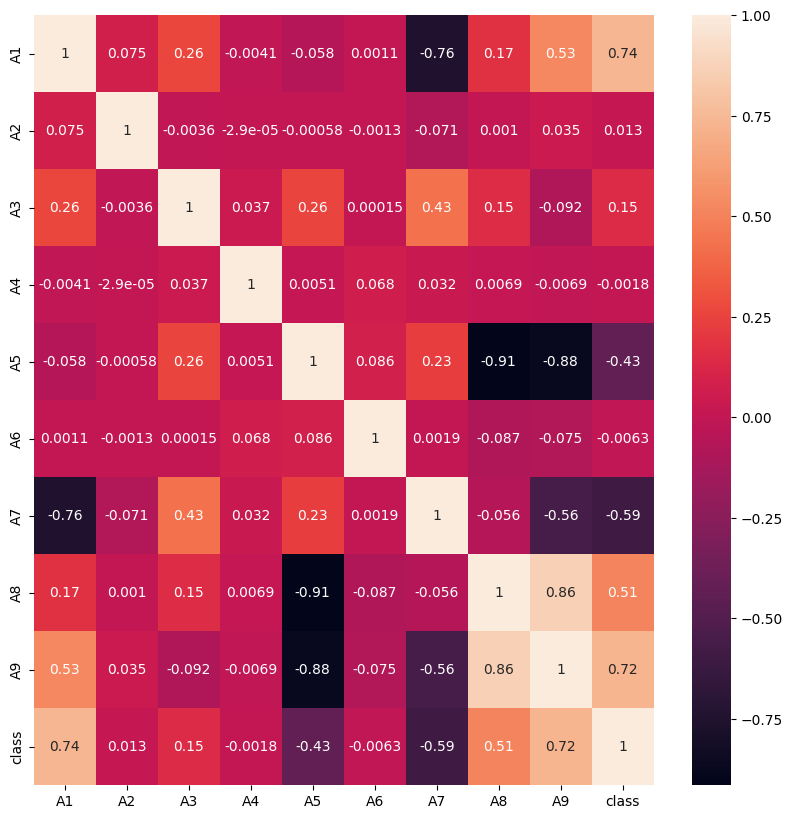

In [229]:
plt.figure(figsize=[10,10])
sns.heatmap(df.corr(), annot=True)

**Insight:**
- Fitur waktu (A1) dan data sensor A9, mampu menjelaskan informasi kondisi sistem shuttle (label) sebesar sekitar 70%
- Fitur data sensor (A5, A7 dan A8), cukup mampu menjelaskan kondisi sistem shuttle (label) sebesar sekitar 40-50%
- Fitur data sensor (A2, A3, A4 dan A6) hampir tidak menjelaskan informasi kondisi sistem shuttle (label), namun bukan berarti tidak penting

**Tindakan:**
- Menggunakan seluruh fitur untuk melatih model

**Alasan:**
- Model decision tree mampu menentukan fitur berpengaruh sendiri
- Fitur merupakan data asli dari sensor shuttle yang penting

# B. Data Preprocesing

In [231]:
df.dropna(inplace=True)

In [232]:
df.isna().sum()

A1       0
A2       0
A3       0
A4       0
A5       0
A6       0
A7       0
A8       0
A9       0
class    0
dtype: int64

In [233]:
df.duplicated().sum()

0

In [234]:
def oversampling(df, threshold, kolom_label):
    for l in df[kolom_label].unique():
        label_len = len(df[df[kolom_label] == l])
        if label_len < threshold:
            selisih = threshold - label_len
            df_l = df[df[kolom_label] == l].sample(selisih, random_state=42, replace=True)
            df = pd.concat([df, df_l], axis=0)

    df = df.reset_index(drop=True)
    return df

In [235]:
def stratified_split(df, kolom_label):
    data_train = pd.DataFrame(columns=df.columns)
    data_test = pd.DataFrame(columns=df.columns)

    for l in df[kolom_label].unique():
        data_l_tr = df[df[kolom_label] == l].sample(frac=0.65, random_state=42)
        data_l_te = df[df[kolom_label] == l].drop(index=data_l_tr.index)

        data_train = pd.concat([data_train, data_l_tr], axis=0)
        data_test = pd.concat([data_test, data_l_te], axis=0)
    
    data_train=data_train.reset_index(drop=True)
    data_test=data_test.reset_index(drop=True)

    x_te = data_test.iloc[:,:-1]
    y_te = data_test[kolom_label]

    return data_train, x_te.values, y_te.values

**Alasan:**
- Menggunakan train sebesar 65% dan test 35%, agar jumlah data minoritas cukup pada data test
- Data train akan dilakukan oversampling 

**Percobaan:**
- Telah mencoba split 70:30, 75:25, 80:20, 85:15. Tetapi justru jumlah data minoritas pada data test sangat sedikit sehingga pada evaluasi presisi dan recall data minoritas sangat buruk 

In [236]:
data_train, x_te, y_te = stratified_split(df, 'class')

C:\Users\mwahy\AppData\Local\Temp\ipykernel_9908\2881624380.py:9: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_train = pd.concat([data_train, data_l_tr], axis=0)
C:\Users\mwahy\AppData\Local\Temp\ipykernel_9908\2881624380.py:10: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  data_test = pd.concat([data_test, data_l_te], axis=0)


<Axes: xlabel='class', ylabel='count'>

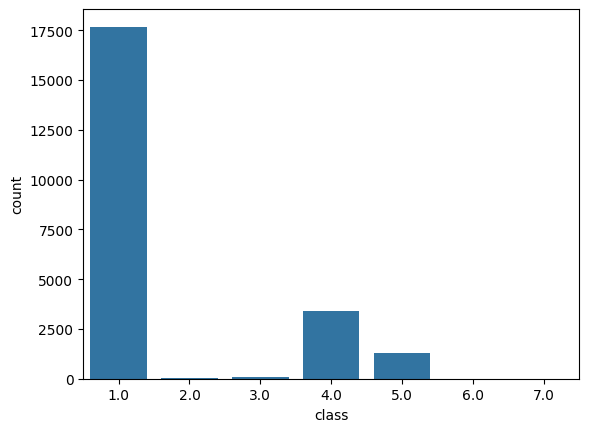

In [237]:
sns.countplot(data=data_train, x='class')

In [238]:
data_train = oversampling(data_train,10000, 'class')

**Alasan:**
- Hanya melakukan oversampling minoritas dan tidak oversampling mayoritas, karena tidak ingin membuang data asli dari sensor
- Dipilih threshold 10000, dikarenakan agar tidak terlalu banyak data manipulasi/duplikat berlebihan sehingga masih agak mencerminkan kondisi asli namun masih cukup untuk memperbaiki performa model pada data minoritas
- Tidak dilakukan metode SMOTE & Noise Injection, karena perubahan sedikitpun pada komponen sensor itu tidak akan mencerminkan keadaan asli

<Axes: xlabel='class', ylabel='count'>

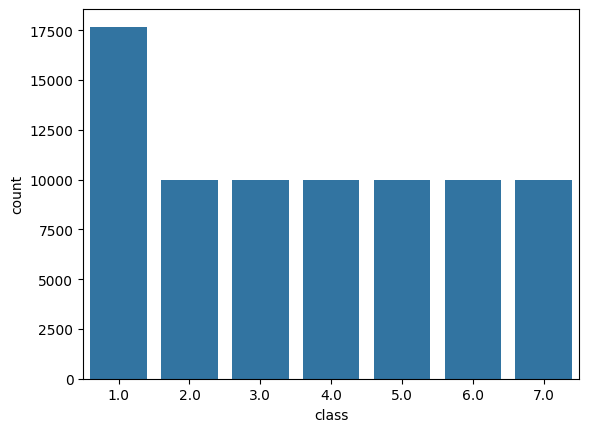

In [239]:
sns.countplot(data=data_train, x='class')

In [240]:
x_tr = data_train.iloc[:,:-1].values
y_tr = data_train['class'].values

In [241]:
print(x_tr.shape)
print(y_tr.shape)
print(x_te.shape)
print(y_te.shape)

(77679, 9)
(77679,)
(12108, 9)
(12108,)


# C. Pemodelan

### Algoritma Decision Tree CART Gini Impurity

**Alasan:**
- Gini Impurity dan Gini Gain lebih mudah dinterpretasikan daripada Entropy dan Information Gain
- Komputasi lebih ringan dan cepat daripada metode ID3 atau C.45
- Bisa digunakan untuk fitur numerik kontinu seperti data hasil sensor shuttle

In [242]:
class DecisionTree:
    def __init__(self, max_depth=5, n_splits=20):
        self.max_depth = max_depth
        self.n_splits = n_splits
        self.tree = None

    # menghitung label paling sering muncul di suatu node
    def most_common_value(self, arr):
        unique, counts = np.unique(arr, return_counts=True)
        return unique[np.argmax(counts)]

    # seberapa campur label pada suatu node
    def gini_impurity(self, y):
        unique, counts = np.unique(y, return_counts=True)
        probs = counts / len(y)
        return 1 - np.sum(probs**2)

    # pengurangan gini impurity setelah percobaan splitiing
    def gini_gain(self, parent, left, right):
        parent_gini = self.gini_impurity(parent)

        left_gini = self.gini_impurity(left)
        right_gini = self.gini_impurity(right)

        left_weight = len(left) / len(parent)
        right_weight = len(right) / len(parent)

        return parent_gini - (left_weight * left_gini + right_weight * right_gini)

    # membangun pohon secara rekrusif
    def build_tree(self, x, y, current_depth):

        # jika kedalaman sudah sama/lebih dari maksimal atau hanya ada 1 jenis label, maka jadikan leaf
        if current_depth >= self.max_depth or len(np.unique(y)) == 1:
            return self.most_common_value(y)

        # cari kombinasi fitur dan nilai threshold terbaik untuk node ini
        best_feature = None
        best_split = None
        best_gain = -np.inf

        # coba untuk setiap fitur
        for feature in range(x.shape[1]):
            values = x[:, feature]

            thresholds = np.linspace(values.min(), values.max(), self.n_splits)

            # coba untuk setiap threshold dari nilai fitur tersebut
            for value in thresholds:

                left_mask = values <= value
                right_mask = values > value

                if left_mask.sum() == 0 or right_mask.sum() == 0:
                    continue

                gain = self.gini_gain(y, y[left_mask], y[right_mask])

                if gain > best_gain:
                    best_feature = feature
                    best_split = value
                    best_gain = gain

        # jika tidak ditemukan fitur terbaik, maka menjadi leaf
        if best_feature is None:
            return self.most_common_value(y)

        # splitting dengan threshold terbaik
        left_mask = x[:, best_feature] <= best_split 
        right_mask = x[:, best_feature] > best_split

        return {
            'feature': best_feature,
            'split': best_split,
            'left': self.build_tree(x[left_mask], y[left_mask], current_depth + 1),
            'right': self.build_tree(x[right_mask], y[right_mask], current_depth + 1)
        }
    
    # melatih model (bangun pohon dari root)
    def fit(self, X, y):
        self.tree = self.build_tree(X, y, 0)

    # prediksi label suatu sampel data baru
    def predict_sample(self, tree, sample):
        # jika node ini bukan dict, maka leaf. kembalikan nilai leaf/label
        if not isinstance(tree, dict):
            return tree

        # threshold node saat ini
        feature_index = tree['feature']
        split_value = tree['split']

        # sampel melalui kondisi setiap node hingga mencapai leaf
        if sample[feature_index] <= split_value:
            return self.predict_sample(tree['left'], sample)
        else:
            return self.predict_sample(tree['right'], sample)

    # prediksi kumpulan sampel data baru
    def predict(self, x_te):
        return np.array([self.predict_sample(self.tree, s) for s in x_te])

In [243]:
def grid_search(depths, x_tr, y_tr, x_te, y_te):
    akurasi_tr = []
    akurasi_te = []
    # hitung akurasi untuk setiap depth
    for depth in depths:
        model = DecisionTree(depth)
        model.fit(x_tr,y_tr)
        
        y_tr_pred = model.predict(x_tr)
        y_te_pred = model.predict(x_te)

        akurasi_tr.append(np.mean(y_tr == y_tr_pred))
        akurasi_te.append(np.mean(y_te == y_te_pred))

        print(f'Depth {depth} (Done)')

    return akurasi_tr, akurasi_te

In [244]:
depths = [d for d in range (3,20)]
akurasi_tr, akurasi_te = grid_search(depths, x_tr,y_tr, x_te, y_te)

Depth 3 (Done)
Depth 4 (Done)
Depth 5 (Done)
Depth 6 (Done)
Depth 7 (Done)
Depth 8 (Done)
Depth 9 (Done)
Depth 10 (Done)
Depth 11 (Done)
Depth 12 (Done)
Depth 13 (Done)
Depth 14 (Done)
Depth 15 (Done)
Depth 16 (Done)
Depth 17 (Done)
Depth 18 (Done)
Depth 19 (Done)


In [245]:
akurasi_tr = pd.DataFrame(data = {'Akurasi Train' : akurasi_tr}, index=depths)
akurasi_te = pd.DataFrame(data = {'Akurasi Test' : akurasi_te}, index=depths)


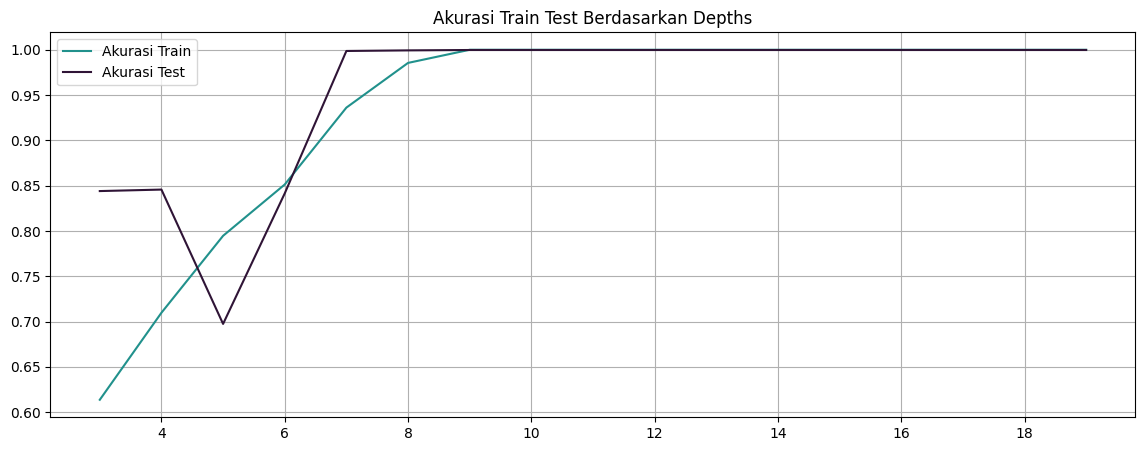

In [246]:
plt.figure(figsize=[14,5])
sns.lineplot(akurasi_tr, palette='viridis')
sns.lineplot(akurasi_te, palette='twilight')
plt.title('Akurasi Train Test Berdasarkan Depths')
plt.legend()
plt.grid()
plt.show()

**Insight:**
- Akurasi terus meningkat dari kedalaman 3 hingga 8
- Akurasi tidak berubah sama sekali/sudah stabil ketika mencapai kedalaman >=9

**Tindakan:**
- Menggunakan kedalaman 9 sebagai kedalaman maksimal yang paling optimal

**Alasan:**
- Pada kedalaman 9, nilai akurasi, presisi, dan recall sudah paling maksimal dan tiak berubah sama sekali
- Kedalaman 9 merupakan jumlah kedalaman yang tidak melebihi jumlah fitur

In [247]:
model = DecisionTree(9)
model.fit(x_tr, y_tr)

In [248]:
y_tr_pred = model.predict(x_tr)
y_te_pred = model.predict(x_te)

# D. Evaluasi Model


In [249]:
def plot_tree(node, feature_names, x=0.5, y=1, dx=0.25, dy=0.08, ax=None, depth=0, max_depth=4):
    if ax is None:
        fig, ax = plt.subplots(figsize=(20,10))
        ax.axis("off")

    if not isinstance(node, dict):
        ax.text(
            x, y,
            f"Class: {node}",
            ha="center",
            bbox=dict(boxstyle="round", fc="#90EE90")
        )
        return ax

    if depth >= max_depth:
        ax.text(
            x, y,
            "...",
            ha="center",
            bbox=dict(boxstyle="round", fc="#f4a261")
        )
        return ax

    feature = feature_names[node["feature"]]
    split = node["split"]

    label = f"{feature} ≤ {split:.2f}"

    ax.text(
        x, y,
        label,
        ha="center",
        bbox=dict(boxstyle="round", fc="#add8e6")
    )

    ax.plot([x, x-dx], [y, y-dy], 'k-')
    plot_tree(node["left"], feature_names, x-dx, y-dy, dx/2, dy, ax, depth+1, max_depth)

    ax.plot([x, x+dx], [y, y-dy], 'k-')
    plot_tree(node["right"], feature_names, x+dx, y-dy, dx/2, dy, ax, depth+1, max_depth)

    return ax

<Axes: >

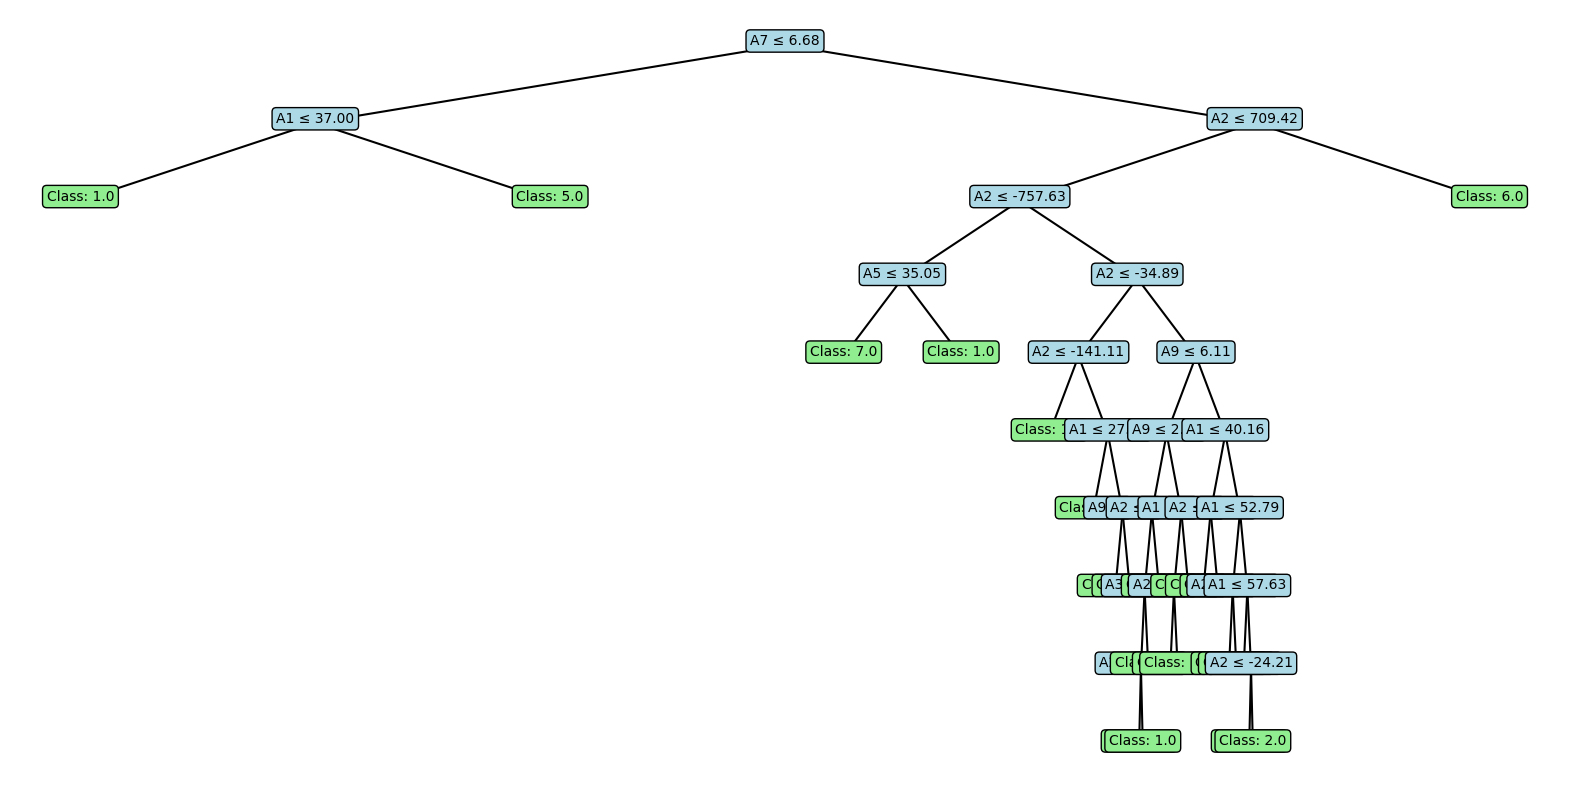

In [250]:
plot_tree(model.tree, df.iloc[:,:-1].columns, max_depth=9)

In [251]:
labels = ['Rad Flow', 'Fpv Close', 'Fpv Open', 'High', 'Bypass', 'Bpv Close', 'Bpv Open']

def evaluasi_model(y, y_pred):
    lbl = np.unique(np.concatenate((y,y_pred)))
    cm = pd.DataFrame(np.zeros([len(lbl), len(lbl)], dtype=int), columns=lbl, index=lbl )

    # buat confussion matrix
    for a, p in zip(y,y_pred):
        cm.loc[a,p] += 1

    print(f'Akurasi : {np.mean(y == y_pred)}')
    print('=' * 40)

    # hitung presisi , recall dan f1 score setiap label
    for l in lbl:
        tp = cm.loc[l,l]
        fp = cm[l].sum() - tp
        fn = cm.loc[l].sum() - tp

        presisi = tp / (tp + fp) if (tp + fp) != 0 else 0
        recall = tp / (tp + fn) if (tp + fn) != 0 else 0
        f1_score = (presisi + recall) / 2

        print(f'Label {labels[int(l)-1]} -------------')
        print(f'Presisi : {presisi:.5f}')
        print(f'Recall : {recall:.5f}')
        print(f'F1 Score : {f1_score:.5f}')

    sns.heatmap(data=cm, fmt='d', annot=True, xticklabels=labels, yticklabels=labels,cmap='Blues')
    plt.xlabel('Predict')
    plt.ylabel('Actual')
    plt.show()
    

note:

presisi -> ketika model mempediksi label A, berapa persen yang memang benar-benar label A

recall -> dari seluruh data dengan label A yang ada, berapa persen yang diprediksi label A

f1 score -> nilai keseimbangan presisi dan recall

Akurasi : 1.0
Label Rad Flow -------------
Presisi : 1.00000
Recall : 1.00000
F1 Score : 1.00000
Label Fpv Close -------------
Presisi : 1.00000
Recall : 1.00000
F1 Score : 1.00000
Label Fpv Open -------------
Presisi : 1.00000
Recall : 1.00000
F1 Score : 1.00000
Label High -------------
Presisi : 1.00000
Recall : 1.00000
F1 Score : 1.00000
Label Bypass -------------
Presisi : 1.00000
Recall : 1.00000
F1 Score : 1.00000
Label Bpv Close -------------
Presisi : 1.00000
Recall : 1.00000
F1 Score : 1.00000
Label Bpv Open -------------
Presisi : 1.00000
Recall : 1.00000
F1 Score : 1.00000


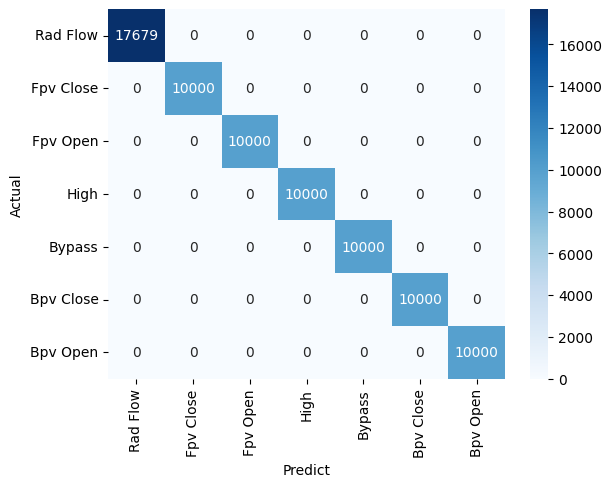

In [252]:
evaluasi_model(y_tr, y_tr_pred)

Akurasi : 0.9997522299306244
Label Rad Flow -------------
Presisi : 0.99989
Recall : 1.00000
F1 Score : 0.99995
Label Fpv Close -------------
Presisi : 0.90909
Recall : 1.00000
F1 Score : 0.95455
Label Fpv Open -------------
Presisi : 1.00000
Recall : 0.97297
F1 Score : 0.98649
Label High -------------
Presisi : 1.00000
Recall : 1.00000
F1 Score : 1.00000
Label Bypass -------------
Presisi : 0.99857
Recall : 1.00000
F1 Score : 0.99928
Label Bpv Close -------------
Presisi : 1.00000
Recall : 0.50000
F1 Score : 0.75000
Label Bpv Open -------------
Presisi : 1.00000
Recall : 0.66667
F1 Score : 0.83333


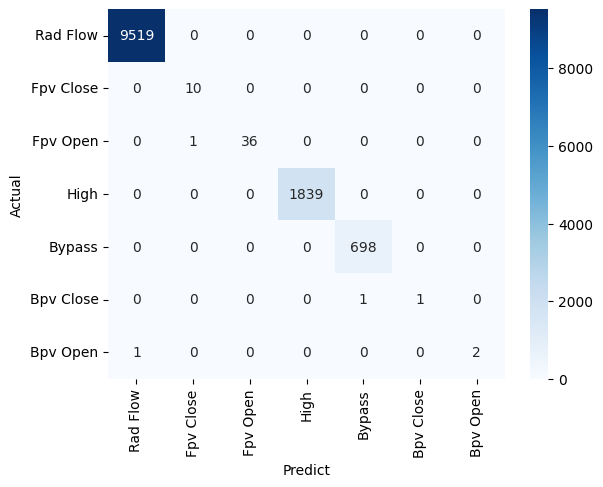

In [253]:
evaluasi_model(y_te, y_te_pred)

### KESIMPULAN

**Performa Model:**
- Berdasarkan perbedaan akurasi train dan test (0.0003), menunjukan model kami dengan kedalaman maksimal 9 ini tidak overfitting. 
- Model sangat baik dalam mempediksi kondisi sistem (rad flow, fpv close, fpv open, high dan bypass).
- Model kurang baik dalam memprediksi kondisi sistem minoritas parah (Bpv close dan bpv open).
- Model kami layak digunakan jika tujuan lebih fokus ke klasifikasi kondisi sistem normal, namun kurang baik jika berfokus ke kondisi sistem alternatif.

**Kemungkinan Efek:**
- Berbahaya jika kondisi shuttle ketika membuka dan menutup jalur alternatif tidak terbaca/terperdiksi, karena model akan menganggap shuttle masih menggunakan jalur fluida normal

**Kemungkinan Penyebab:**
- Data yang imbalanced parah
- Penanganan nilai kosong kurang sesuai

**Kemungkinan Optimasi Kedepanya:**
- Mencoba penanganan nilai kosong dengan mean/median dan lihat hasilnya
- Mencoba algoritma turunan decision tree yang lebih akurat (random forest)

# E. GUI

In [ ]:
from tkinter import *
from tkinter import messagebox

def submit():
    try:
        a1 = float(input_a1.get())
        a2 = float(input_a2.get())
        a3 = float(input_a3.get())
        a4 = float(input_a4.get())
        a5 = float(input_a5.get())
        a6 = float(input_a6.get())
        a7 = float(input_a7.get())
        a8 = float(input_a8.get())
        a9 = float(input_a9.get())

        df_baru = pd.DataFrame(data={
            'A1' : [a1],
            'A2' : [a2],
            'A3' : [a3],
            'A4' : [a4],
            'A5' : [a5],
            'A6' : [a6],
            'A7' : [a7],
            'A8' : [a8],
            'A9' : [a9],
        },index=[0])

        x_baru = df_baru.values

        y_pred_baru = model.predict(x_baru)

        match int(y_pred_baru[0]):
            case 1:
                y_pred_baru = '1 Rad Flow'
            case 2:
                y_pred_baru = '2 Fpv Close'
            case 3:
                y_pred_baru = '3 Fpv Open'
            case 4:
                y_pred_baru = '4 High'
            case 5:
                y_pred_baru = '5 Bypass'
            case 6:
                y_pred_baru = '6 Bpv Close'
            case 7:
                y_pred_baru = '7 Bpv Open'

        messagebox.showinfo('Kondisi Sistem', f'Kondisi Sistem {y_pred_baru}')
            
    except ValueError:
        messagebox.showerror('ValueError', 'Masukan data yang valid')


bg_color = "#222A38"
fg_color = 'whitesmoke'
input_color = "#161C25"
btn_color = "#07929C"

window = Tk()
window.configure(bg=bg_color)

lbl_judul = Label(text='Klasifikasi Kondisi Sistem Shuttle', bg=bg_color, fg=fg_color, font=['Arial', 15, 'bold'])
lbl_judul.pack(pady=10, padx=10)

lbl_spasi = Label(bg=bg_color)
lbl_spasi.pack(pady=5)


lbl_a1 = Label(text='Masukan Data Waktu (A1):' , bg=bg_color, fg = fg_color, font=['Arial', 10])
lbl_a1.pack(pady=5)
input_a1 = Entry(bg=input_color, fg=fg_color)
input_a1.pack(pady=3)

lbl_a2 = Label(text='Masukan Nilai Data Sensor A2:' , bg=bg_color, fg = fg_color, font=['Arial', 10])
lbl_a2.pack(pady=5)
input_a2 = Entry(bg=input_color, fg=fg_color)
input_a2.pack(pady=3)

lbl_a3 = Label(text='Masukan Nilai Data Sensor A3:' , bg=bg_color, fg = fg_color, font=['Arial', 10])
lbl_a3.pack(pady=5)
input_a3 = Entry(bg=input_color, fg=fg_color)
input_a3.pack(pady=3)

lbl_a4 = Label(text='Masukan Nilai Data Sensor A4:' , bg=bg_color, fg = fg_color, font=['Arial', 10])
lbl_a4.pack(pady=5)
input_a4 = Entry(bg=input_color, fg=fg_color)
input_a4.pack(pady=3)

lbl_a5 = Label(text='Masukan Nilai Data Sensor A5:' , bg=bg_color, fg = fg_color, font=['Arial', 10])
lbl_a5.pack(pady=5)
input_a5 = Entry(bg=input_color, fg=fg_color)
input_a5.pack(pady=3)

lbl_a6 = Label(text='Masukan Nilai Data Sensor A6:' , bg=bg_color, fg = fg_color, font=['Arial', 10])
lbl_a6.pack(pady=5)
input_a6 = Entry(bg=input_color, fg=fg_color)
input_a6.pack(pady=3)

lbl_a7 = Label(text='Masukan Nilai Data Sensor A7:' , bg=bg_color, fg = fg_color, font=['Arial', 10])
lbl_a7.pack(pady=5)
input_a7 = Entry(bg=input_color, fg=fg_color)
input_a7.pack(pady=3)

lbl_a8 = Label(text='Masukan Nilai Data Sensor A8:' , bg=bg_color, fg = fg_color, font=['Arial', 10])
lbl_a8.pack(pady=5)
input_a8 = Entry(bg=input_color, fg=fg_color)
input_a8.pack(pady=3)

lbl_a9 = Label(text='Masukan Nilai Data Sensor A9:' , bg=bg_color, fg = fg_color, font=['Arial', 10])
lbl_a9.pack(pady=5)
input_a9 = Entry(bg=input_color, fg=fg_color)
input_a9.pack(pady=3)

btn_predict = Button(text='Prediksi', bg=btn_color, fg=fg_color, font=['Arial', 13, 'bold'], command=submit)
btn_predict.pack(pady=30)

window.mainloop()